# Análisis de Frecuencias Reales

Listaremos directamente los n-gramas más frecuentes que arroja el dataset, sin buscar palabras predefinidas, para descubrir cuáles son empíricamente los mejores predictores.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('..')
from src.analisis_frecuencias import get_top_ngrams

df = pd.read_csv("../data/cleaned/train_cleaned.csv")
disaster_tweets = df[df['target'] == 1]['text']
normal_tweets = df[df['target'] == 0]['text']


## 1. Top Unigramas (1 palabra) por Clase

C:\Users\hdaniyyel\AppData\Local\Temp\ipykernel_29620\721234684.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_disaster, x='count', y='ngram', ax=axes[0], palette='Reds_d')


C:\Users\hdaniyyel\AppData\Local\Temp\ipykernel_29620\721234684.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_normal, x='count', y='ngram', ax=axes[1], palette='Blues_d')


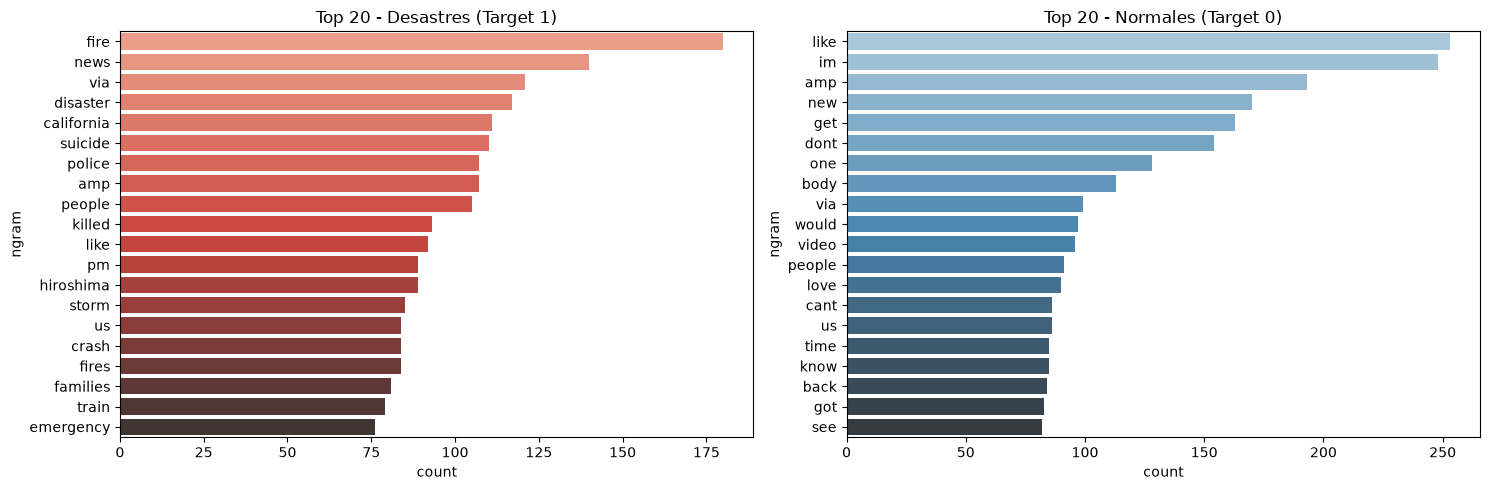

In [2]:
top_disaster = get_top_ngrams(disaster_tweets, ngram_range=(1,1), top_k=20)
top_normal = get_top_ngrams(normal_tweets, ngram_range=(1,1), top_k=20)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=top_disaster, x='count', y='ngram', ax=axes[0], palette='Reds_d')
axes[0].set_title('Top 20 - Desastres (Target 1)')

sns.barplot(data=top_normal, x='count', y='ngram', ax=axes[1], palette='Blues_d')
axes[1].set_title('Top 20 - Normales (Target 0)')

plt.tight_layout()
plt.show()


## 2. Comparación: Bigramas vs Trigramas (Clase Desastres)

C:\Users\hdaniyyel\AppData\Local\Temp\ipykernel_29620\4067129317.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_bigrams, x='count', y='ngram', ax=axes[0], palette='Reds_d')
C:\Users\hdaniyyel\AppData\Local\Temp\ipykernel_29620\4067129317.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_trigrams, x='count', y='ngram', ax=axes[1], palette='Oranges_d')


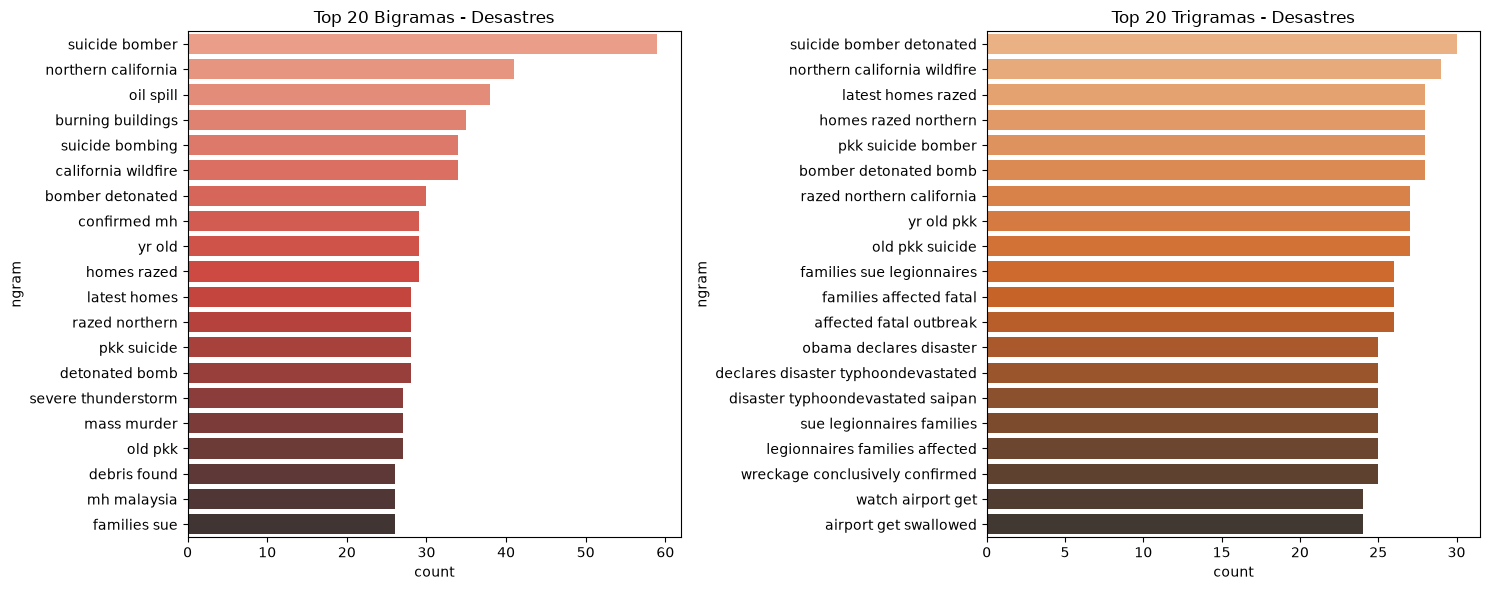

In [3]:
top_bigrams = get_top_ngrams(disaster_tweets, ngram_range=(2,2), top_k=20)
top_trigrams = get_top_ngrams(disaster_tweets, ngram_range=(3,3), top_k=20)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(data=top_bigrams, x='count', y='ngram', ax=axes[0], palette='Reds_d')
axes[0].set_title('Top 20 Bigramas - Desastres')

sns.barplot(data=top_trigrams, x='count', y='ngram', ax=axes[1], palette='Oranges_d')
axes[1].set_title('Top 20 Trigramas - Desastres')

plt.tight_layout()
plt.show()


## Notas sobre frecuencias

**¿Qué palabras discriminan mejor?**
La clase 0 (normal) es puro ruido coloquial: *like, im, amp, new, get, dont*. No aportan señal. 
La clase 1 (desastres) expone el núcleo del problema: *fire, news, disaster, california, suicide, police, killed*. 
Si un tweet dice *fire* o *killed*, el modelo ya tiene la mitad del trabajo hecho.

**Bigramas vs Trigramas**
Los bigramas agrupan conceptos útiles. *suicide bomber* (59 veces), *northern california* (41). Construyen contexto real.

Los trigramas son una trampa. Textos largos como *latest homes razed* repitiéndose 30 veces seguidas no es lenguaje orgánico. Son bots o cadenas de noticias reciclando el mismo titular. 
Si metes trigramas, vas a sobreajustar tu modelo a las noticias exactas del día en que se armó el dataset. Ignóralos. Quédate con los bigramas como límite.